In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score, KFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score




In [1]:
data = pd.read_csv(r"C:\Users\USER\Downloads\Cellphone.csv")

NameError: name 'pd' is not defined

In [2]:
data.head()

NameError: name 'data' is not defined

In [8]:
data.columns
outliers = ['Price', 'Sale', 'weight', 'resoloution', 'ppi',
       'cpu core', 'cpu freq', 'internal mem', 'ram', 'RearCam', 'Front_Cam',
       'battery', 'thickness']
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Product_id    161 non-null    int64  
 1   Price         161 non-null    int64  
 2   Sale          161 non-null    int64  
 3   weight        161 non-null    float64
 4   resoloution   161 non-null    float64
 5   ppi           161 non-null    int64  
 6   cpu core      161 non-null    int64  
 7   cpu freq      161 non-null    float64
 8   internal mem  161 non-null    float64
 9   ram           161 non-null    float64
 10  RearCam       161 non-null    float64
 11  Front_Cam     161 non-null    float64
 12  battery       161 non-null    int64  
 13  thickness     161 non-null    float64
dtypes: float64(8), int64(6)
memory usage: 17.7 KB


In [9]:
for i in outliers:
    Q1 = data[i].quantile(0.25)
    Q3 = data[i].quantile(0.75)

    IQR = Q3 - Q1

    upperbound = Q3 + 1.5*IQR
    lowerbound = Q1 - 1.5 * IQR

    data[i]= data[i].clip(lowerbound, upperbound)

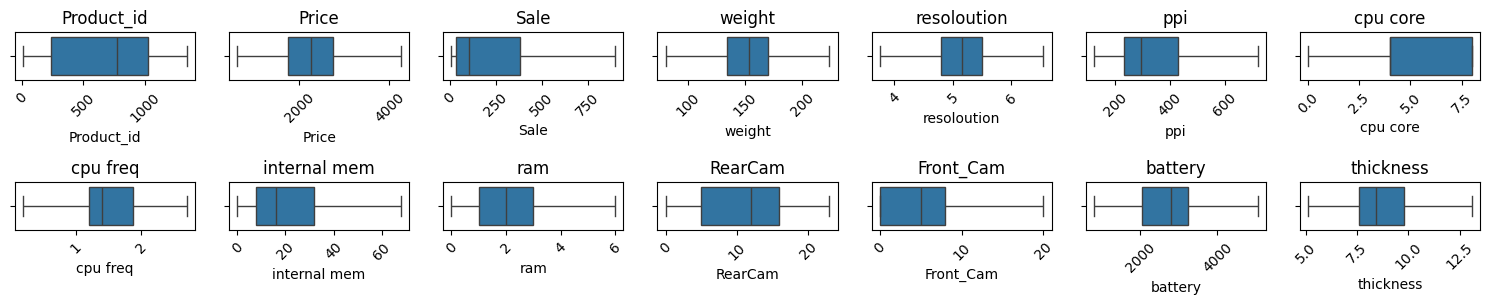

In [10]:
plt.figure(figsize = (15, 10))

for idx, col in enumerate(data.columns):
    plt.subplot(7, 7, idx + 1)  # Specify position in grid
    sns.boxplot(data=data, x=col)
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [11]:
X = data.drop(columns = ['Price', 'Product_id'], axis = 1)
Y = data['Price']

In [12]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state = 43),
    "Gradient Boosting": GradientBoostingRegressor(random_state = 43),
    "SVR": SVR(),
    "KNN": KNeighborsRegressor()
}
cv = KFold(n_splits = 5, shuffle =True, random_state = 43)

for name, model in models.items():
    pipe = Pipeline([
         ("scaler", StandardScaler()),
         ("regressor", model)
    ])

    scores = cross_val_score(pipe, X, Y, cv =cv, scoring = 'r2')

    print(f"\n{name}")
    print("R2 Scores:", scores)
    print("Mean R2:", scores.mean())
    print("Std Dev:", scores.std())


Linear Regression
R2 Scores: [0.87737853 0.95509327 0.96611306 0.9474206  0.94100671]
Mean R2: 0.9374024340013385
Std Dev: 0.03115602567873197

Random Forest
R2 Scores: [0.94281469 0.98565606 0.97889671 0.97486438 0.98179935]
Mean R2: 0.972806237287038
Std Dev: 0.015406601830217723

Gradient Boosting
R2 Scores: [0.96461409 0.99741409 0.99334583 0.9954891  0.99638716]
Mean R2: 0.9894500523321547
Std Dev: 0.012490167894916695

SVR
R2 Scores: [0.01347932 0.01006742 0.01618527 0.02994878 0.02494522]
Mean R2: 0.018925202106723927
Std Dev: 0.007394391676652243

KNN
R2 Scores: [0.79230459 0.90713861 0.93088656 0.93326068 0.90579288]
Mean R2: 0.8938766644732141
Std Dev: 0.05206840746715731


In [13]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 43)

In [16]:
final_pipe = Pipeline([
       ("scaler", StandardScaler()),
    ("regressor", GradientBoostingRegressor(random_state = 43))
 
])


In [17]:
param_dist = {
    "regressor__n_estimators": [100, 200, 500],
    "regressor__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "regressor__max_depth": [3, 4, 5, 6],
    "regressor__min_samples_split": [2, 5, 10],
    "regressor__min_samples_leaf": [1, 2, 4],
    "regressor__subsample": [0.8, 0.9, 1.0],
    "regressor__max_features": ["sqrt", "log2", None],
    "regressor__loss": ["squared_error", "absolute_error", "huber"]
}

random_search = RandomizedSearchCV(
    final_pipe,
    param_distributions = param_dist,
    n_iter = 20,
    cv = 5,
    scoring="neg_mean_squared_error",  # since it's regression
    n_jobs= 1,
    random_state=42
)

random_search.fit(X_train, Y_train)

print("Best Parameters:", random_search.best_params_)
print("Best Score (MSE):", -random_search.best_score_)  # negative because sklearn flips the sign


Best Parameters: {'regressor__subsample': 0.9, 'regressor__n_estimators': 500, 'regressor__min_samples_split': 5, 'regressor__min_samples_leaf': 4, 'regressor__max_features': None, 'regressor__max_depth': 5, 'regressor__loss': 'huber', 'regressor__learning_rate': 0.05}
Best Score (MSE): 16412.603398924974


In [20]:
best_param = random_search.best_params_

for para, value in best_param.items():
    print(f"{para}:{value}\n")

regressor__subsample:0.9

regressor__n_estimators:500

regressor__min_samples_split:5

regressor__min_samples_leaf:4

regressor__max_features:None

regressor__max_depth:5

regressor__loss:huber

regressor__learning_rate:0.05



In [21]:
final_pipe = Pipeline([
       ("scaler", StandardScaler()),
    ("regressor", GradientBoostingRegressor(loss = 'huber', learning_rate = 0.05, n_estimators = 500, subsample = 0.9,
                                           min_samples_split = 5, min_samples_leaf = 4, max_depth = 5, random_state = 43))
 
])


In [26]:
final_pipe.fit(X_train, Y_train)
pred = final_pipe.predict(X_test)

print("Evaluation Metrics: \n")
print(r2_score(Y_test, pred))
print(mean_absolute_error(Y_test, pred))
print(mean_squared_error(Y_test, pred))

Evaluation Metrics: 

0.9287118396720105
82.76967318604666
29357.18948060855


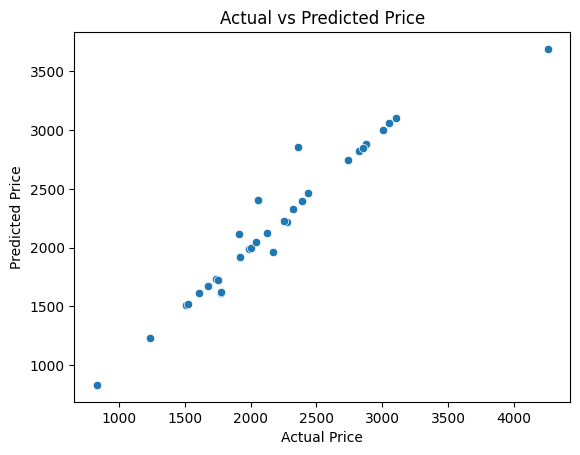

In [24]:
sns.scatterplot(x=Y_test, y=pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()

In [25]:
new_data = pd.DataFrame([{
    'Sale':12, 'weight':140.0, 'resoloution': 5.5, 'ppi':450,
    'cpu core':4, 'cpu freq':1.875, 'internal mem':128.0,
    'ram':6.000, 'RearCam':12.00, 'Front_Cam':16.0,
    'battery':4080, 'thickness':8.4
}])

pred_price = final_pipe.predict(new_data)
print(f"\nThe predicted mobile price is {pred_price[0]:.2f}")


The predicted mobile price is 3398.58


In [27]:
import joblib

# final_pipe is the pipeline you trained (StandardScaler + GradientBoostingRegressor)
joblib.dump(final_pipe, "phone_price_model.pkl")

['phone_price_model.pkl']